In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import collections, transforms
import os
import re
import matplotlib.tri as tri
from tqdm.notebook import tqdm
from tqdm import notebook
import time
from scipy.spatial import cKDTree

In [44]:
# Восстановление карты границ
print("Восстановление карты границ...")
boundary_edges_map = {}  

Восстановление карты границ...


In [45]:
mark_start  = re.compile(r"\(2\s(?P<DIMEN>2|3)\)")
mark_nodes  = re.compile(r"\(10\s\((\d)\s([a-zA-Z0-9]+)\s([a-zA-Z0-9]+)\s([a-zA-Z0-9]+)\s([a-zA-Z0-9]+)\)\(")
mark_nodes_icem  =re.compile(r"\(10\s\(([a-zA-Z0-9]+)\s([a-zA-Z0-9]+)\s([a-zA-Z0-9]+)\s([a-zA-Z0-9]+)\s([a-zA-Z0-9]+)")
mark_faces  =     re.compile(r"\(13\s\(([a-zA-Z0-9]+)\s([a-zA-Z0-9]+)\s([a-zA-Z0-9]+)\s([a-zA-Z0-9]+)\s([a-zA-Z0-9]+)\)\(")
mark_ends   = re.compile(r"\)\)")
mark_ends_icem   = re.compile(r"\)")

In [46]:
filename = "F:/Kaspersky/HUPC/第八/ansys/mesh1.msh"

In [47]:
facename2properties = []
nodes_list = []
node2zone = []
inter_faces = []
zone_index = []
faces2zone = []
node_id_to_index = {}
all_nodes_list = []

with open(filename, "r") as f:
    # Чтение размерности сетки
    for line in f:
        if re.search(mark_start, line):
            match = re.search(r"\(2\s(?P<DIMEN>2|3)\)", line)
            if match:
                dimension = match.group('DIMEN')
                print('Размерность сетки:', dimension)
                if dimension != '2':
                    print('Обработка для 3D сетки еще не выполнена')
                    exit()
            break
    
    current_line = 0
    for line in f:
        current_line += 1
        # Чтение узлов
        if re.search(mark_nodes_icem, line) and line.strip()[-1] != ')':
            try:
                obj = line[5:-2].split()
                n1 = int(obj[1], 16)
                nn = int(obj[2], 16)
                node2zone.append([n1, nn])
                num_nodes = nn - n1 + 1
                
                k = 0
                while True:
                    line = f.readline()
                    current_line += 1
                    if not line:  
                        break
                    stripped = line.strip()
                    if stripped.endswith(')'):  
                        break
                    if stripped:  
                        extracted = [float(s) for s in stripped.split()]
                        node_id = n1 + k
                        node_id_to_index[node_id] = len(all_nodes_list)
                        all_nodes_list.append(extracted)
                        k += 1
            except Exception as e:
                print(f"Ошибка при обработке строки {current_line}: {line}")
                print(f"Ошибка: {str(e)}")
                raise
        
        # Чтение граней
        if re.search(mark_faces, line):
            try:
                obj = line[5:-3].split()
                zone_index.append(int(obj[0], 16))
                n1 = int(obj[1], 16)
                nn = int(obj[2], 16)
                faces2zone.append([n1, nn])
                
                while True:
                    line = f.readline()
                    current_line += 1
                    if not line:  
                        break
                    stripped = line.strip()
                    if stripped.endswith(')'):  
                        break
                    if stripped:  
                        extracted = [int(s, 16) for s in stripped.split()]
                        inter_faces.append(extracted)
            except Exception as e:
                print(f"Ошибка при обработке строки {current_line}: {line}")
                print(f"Ошибка: {str(e)}")
                raise
        
        # Чтение граничных условий
        if re.search(r"45|39", line):
            try:
                obj = line[5:-5].split()
                facename2properties.append(obj)
            except Exception as e:
                print(f"Ошибка при обработке строки {current_line}: {line}")
                print(f"Ошибка: {str(e)}")
                raise

nodes_arr = np.array(all_nodes_list)
print(f"Всего узлов: {nodes_arr.shape[0]}")

if inter_faces:
    inter_faces = np.array(inter_faces)
else:
    inter_faces = np.empty((0, 5), dtype=int)

Размерность сетки: 2
Всего узлов: 2231


In [48]:
# Построение массива идентификаторов зон
if len(inter_faces) > 0:
    face_zone_ids = -np.ones(len(inter_faces), dtype=int)
    current_index = 0
    for i in range(len(zone_index)):
        start = faces2zone[i][0]
        end = faces2zone[i][1]
        num_faces = end - start + 1
        face_zone_ids[current_index:current_index+num_faces] = zone_index[i]
        current_index += num_faces

    if current_index != len(inter_faces):
        print(f"Warning: Incomplete area ID assignment ({current_index} vs {len(inter_faces)})")
else:
    face_zone_ids = np.array([], dtype=int)

In [49]:
# Создание карты границ 
for prop in facename2properties:
    if len(prop) >= 3:
        zone_id = int(prop[0])
        bc_name = prop[2]
        
        if bc_name not in boundary_edges_map:
            boundary_edges_map[bc_name] = []
        
        print(f"Processing boundaries: {bc_name} (Region ID={zone_id})")
        
        face_indices = np.where(face_zone_ids == zone_id)[0]
        print(f"  have found {len(face_indices)} Face")
        
        for i in face_indices:
            node1 = inter_faces[i, 0]
            node2 = inter_faces[i, 1]
            
            idx1 = node_id_to_index.get(node1)
            idx2 = node_id_to_index.get(node2)
            
            if idx1 is not None and idx2 is not None:
                R1, Z1 = nodes_arr[idx1]
                R2, Z2 = nodes_arr[idx2]
                
                dR = R2 - R1
                dZ = Z2 - Z1
                L = np.sqrt(dR**2 + dZ**2)
                
                boundary_edges_map[bc_name].append([idx1, idx2, L])

Processing boundaries: interior-all (Region ID=1)
  have found 5929 Face
Processing boundaries: all (Region ID=4)
  have found 0 Face
Processing boundaries: crowntop1 (Region ID=5)
  have found 2 Face
Processing boundaries: crowntop2 (Region ID=6)
  have found 2 Face
Processing boundaries: crowntop3 (Region ID=7)
  have found 2 Face
Processing boundaries: crowntop (Region ID=8)
  have found 64 Face
Processing boundaries: skirt1 (Region ID=9)
  have found 4 Face
Processing boundaries: skirt2 (Region ID=10)
  have found 5 Face
Processing boundaries: skirt3 (Region ID=11)
  have found 5 Face
Processing boundaries: skirt4 (Region ID=12)
  have found 5 Face
Processing boundaries: skirt5 (Region ID=13)
  have found 6 Face
Processing boundaries: skirt6 (Region ID=14)
  have found 2 Face
Processing boundaries: pinbore (Region ID=15)
  have found 33 Face
Processing boundaries: walloutside (Region ID=16)
  have found 66 Face
Processing boundaries: wallinside (Region ID=17)
  have found 101 Face


In [50]:
print(facename2properties)
print(nodes_arr.shape)
print(len(inter_faces))
print(node2zone)
print(zone_index)
print(faces2zone)

[['1', 'interior', 'interior-all'], ['4', 'solid', 'all'], ['5', 'wall', 'crowntop1'], ['6', 'wall', 'crowntop2'], ['7', 'wall', 'crowntop3'], ['8', 'wall', 'crowntop'], ['9', 'wall', 'skirt1'], ['10', 'wall', 'skirt2'], ['11', 'wall', 'skirt3'], ['12', 'wall', 'skirt4'], ['13', 'wall', 'skirt5'], ['14', 'wall', 'skirt6'], ['15', 'wall', 'pinbore'], ['16', 'wall', 'walloutside'], ['17', 'wall', 'wallinside'], ['18', 'wall', 'geom___']]
(2231, 2)
6311
[[1, 1849], [1850, 2231]]
[1, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
[[1, 5929], [5930, 5931], [5932, 5933], [5934, 5935], [5936, 5999], [6000, 6003], [6004, 6008], [6009, 6013], [6014, 6018], [6019, 6024], [6025, 6026], [6027, 6059], [6060, 6125], [6126, 6226], [6227, 6311]]


In [51]:
inter_faces_inline = np.array(inter_faces)
inter_faces_inline = np.vstack((inter_faces_inline[:, 0:3], inter_faces_inline[:, [0, 1, 3]]))
inter_faces_inline = inter_faces_inline[inter_faces_inline[:,2]>0]

In [52]:
# Построение списка узлов каждого элемента
el_nodes = {}
for i in tqdm(range(len(inter_faces))):
    face = inter_faces[i]
    node1_id = face[0]
    node2_id = face[1]
    
    node1_idx = node_id_to_index.get(node1_id, -1)
    node2_idx = node_id_to_index.get(node2_id, -1)
    
    left_elem = face[2] - 1  
    right_elem = face[3] - 1 if face[3] > 0 else -1  
    
    if left_elem not in el_nodes:
        el_nodes[left_elem] = set()
    if node1_idx != -1:
        el_nodes[left_elem].add(node1_idx)
    if node2_idx != -1:
        el_nodes[left_elem].add(node2_idx)
    
    if right_elem != -1:
        if right_elem not in el_nodes:
            el_nodes[right_elem] = set()
        if node1_idx != -1:
            el_nodes[right_elem].add(node1_idx)
        if node2_idx != -1:
            el_nodes[right_elem].add(node2_idx)

  0%|          | 0/6311 [00:00<?, ?it/s]

In [53]:
ne = max(inter_faces_inline[:,2])

In [54]:
# Формирование списка узлов элементов
el_list = np.full((ne, 4), -1, dtype=int)  
for elem_idx, nodes_set in el_nodes.items():
    nodes = list(nodes_set)
    if len(nodes) > 4:  
        nodes = nodes[:4]
    el_list[elem_idx, :len(nodes)] = nodes

In [55]:
# Упорядочивание узлов элемента
for i in notebook.tqdm(range(ne)):
    if el_list[i, -1] != -1:  
        # Use the correct node index
        node_indices = el_list[i, :]
        x = nodes_arr[node_indices, 0]
        y = nodes_arr[node_indices, 1]
        
        cx = x.mean()
        cy = y.mean()
        
        angles = np.arctan2(y - cy, x - cx)  
        indices = np.argsort(angles)
        el_list[i, :] = el_list[i, indices]

  0%|          | 0/4080 [00:00<?, ?it/s]

In [56]:
# Характеристики элементов: центр, площадь
el_quantities = np.zeros((ne, 3))
for i in tqdm(range(ne)):
    # Get valid node index (filter out -1)
    node_indices = el_list[i, :]
    valid_indices = node_indices[node_indices >= 0]
    
    if len(valid_indices) < 3:  
        if len(valid_indices) > 0:
            x = nodes_arr[valid_indices, 0]
            y = nodes_arr[valid_indices, 1]
            cx, cy = np.mean(x), np.mean(y)
            area = 0
        else:
            cx, cy, area = 0, 0, 0
    else:
        x = nodes_arr[valid_indices, 0]
        y = nodes_arr[valid_indices, 1]
        
        cx = np.mean(x)
        cy = np.mean(y)
        
        area = 0
        n = len(valid_indices)
        for j in range(n):
            x1, y1 = x[j], y[j]
            x2, y2 = x[(j + 1) % n], y[(j + 1) % n]
            area += (x1 * y2 - x2 * y1)
        area = abs(area) / 2
    
    el_quantities[i, 0] = cx
    el_quantities[i, 1] = cy
    el_quantities[i, 2] = area

  0%|          | 0/4080 [00:00<?, ?it/s]

In [57]:
# Вычисление параметров граней
nf = len(inter_faces)  

face_quantities = np.full((nf, 20), fill_value=-1.0, dtype=float)
inner_mask = inter_faces[:, 3] > 0  
inner_indices = np.where(inner_mask)[0]
boundary_indices = np.where(~inner_mask)[0]

# Обработка внутренних граней
for i in notebook.tqdm(inner_indices):
    node1_id = inter_faces[i, 0]
    node2_id = inter_faces[i, 1]
    node1_idx = node_id_to_index.get(node1_id)
    node2_idx = node_id_to_index.get(node2_id)
    
    if node1_idx is None or node2_idx is None:
        continue
        
    elem1_idx = inter_faces[i, 2] - 1  
    elem2_idx = inter_faces[i, 3] - 1  
    
    rf = 0.5 * (nodes_arr[node1_idx] + nodes_arr[node2_idx])
    
    dr = nodes_arr[node2_idx] - nodes_arr[node1_idx]
    Sf = np.array([dr[1], -dr[0]])  
    
    rC = el_quantities[elem1_idx, 0:2]
    rF = el_quantities[elem2_idx, 0:2]
    
    dCF = rF - rC
    
    dCF_norm_sq = np.dot(dCF, dCF)
    if dCF_norm_sq > 1e-10:  
        t = np.dot(rf - rC, dCF) / dCF_norm_sq
        rf_prime = rC + t * dCF
    else:
        rf_prime = rf  
    
    face_quantities[i, 0:2] = dCF
    face_quantities[i, 2] = np.linalg.norm(dCF)
    face_quantities[i, 5:7] = np.sign(np.dot(dCF, Sf)) * Sf
    face_quantities[i, 10:12] = rf - rf_prime
    face_quantities[i, 12] = np.linalg.norm(rF - rf_prime) / max(face_quantities[i, 2], 1e-10)
    face_quantities[i, 18:20] = rf

# Обработка граничных граней
for i in notebook.tqdm(boundary_indices):
    node1_id = inter_faces[i, 0]
    node2_id = inter_faces[i, 1]
    node1_idx = node_id_to_index.get(node1_id)
    node2_idx = node_id_to_index.get(node2_id)
    
    if node1_idx is None or node2_idx is None:
        continue
        
    elem_idx = inter_faces[i, 2] - 1  
    
    rb = 0.5 * (nodes_arr[node1_idx] + nodes_arr[node2_idx])
    
    dr = nodes_arr[node2_idx] - nodes_arr[node1_idx]
    Sf = np.array([dr[1], -dr[0]])  
    
    rC = el_quantities[elem_idx, 0:2]
    
    dCb = rb - rC
    
    face_quantities[i, 0:2] = dCb
    face_quantities[i, 2] = np.linalg.norm(dCb)
    face_quantities[i, 5:7] = np.sign(np.dot(dCb, Sf)) * Sf
    face_quantities[i, 10:12] = [0, 0]
    face_quantities[i, 12] = 0
    face_quantities[i, 18:20] = rb

# Вычисление производных величин
valid_mask = face_quantities[:, 2] > 1e-10  # Filter out faces with very small length
face_quantities[valid_mask, 3:5] = face_quantities[valid_mask, 0:2] / face_quantities[valid_mask, 2, np.newaxis]
face_quantities[:, 7] = np.linalg.norm(face_quantities[:, 5:7], axis=1)

valid_sf_mask = face_quantities[:, 7] > 1e-10
face_quantities[valid_sf_mask, 8:10] = face_quantities[valid_sf_mask, 5:7] / face_quantities[valid_sf_mask, 7, np.newaxis]

dot_products = np.sum(face_quantities[:, 3:5] * face_quantities[:, 8:10], axis=1)
face_quantities[:, 13:15] = (dot_products[:, np.newaxis] * face_quantities[:, 3:5])

face_quantities[:, 15:17] = face_quantities[:, 5:7] - face_quantities[:, 13:15]

face_quantities[:, 17] = np.linalg.norm(face_quantities[:, 15:17], axis=1)

  0%|          | 0/5929 [00:00<?, ?it/s]

  0%|          | 0/382 [00:00<?, ?it/s]

In [58]:
def plot_fem_mesh(nodes_xy, elements, el_centers, xlim, ylim):
    """Построение конечно-элементной сетки"""
    xmin, xmax = xlim
    ymin, ymax = ylim
    
    nodes_xy = np.array(nodes_xy)
    
    for i, element in notebook.tqdm(enumerate(elements), total=len(elements)):
        if (xmin < el_centers[i, 0] < xmax) and (ymin < el_centers[i, 1] < ymax):
            node_indices = element[element >= 0]  
            
            x_coords = nodes_xy[node_indices, 0]
            y_coords = nodes_xy[node_indices, 1]
            
            x_coords = np.append(x_coords, x_coords[0])
            y_coords = np.append(y_coords, y_coords[0])
            
            plt.plot(x_coords, y_coords, 'k-', linewidth=0.5)

  0%|          | 0/4080 [00:00<?, ?it/s]

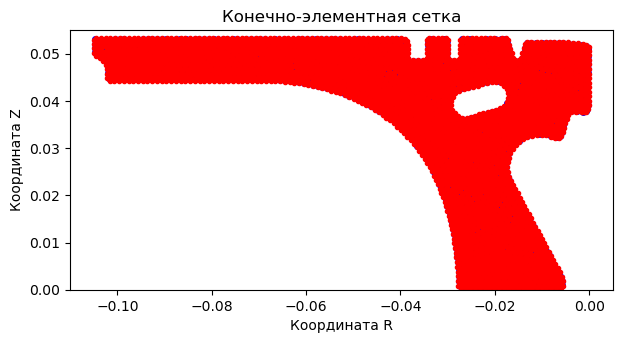

In [59]:
fig2, ax2 = plt.subplots(figsize=(7,7))
ax2.set_aspect('equal')
xlim = [-0.11, 0.005]
ylim = [0.0, 0.055]

plot_fem_mesh(nodes_arr, el_list, el_quantities, xlim, ylim)

ax2.plot(el_quantities[:, 0], el_quantities[:, 1], 'bo', markersize=4)
ax2.plot(face_quantities[:,18], face_quantities[:,19], 'ro', markersize=3)

ax2.set_xlim(xlim)
ax2.set_ylim(ylim)
ax2.set_title('Конечно-элементная сетка')
ax2.set_xlabel('Координата R')
ax2.set_ylabel('Координата Z')
plt.show()

In [60]:
# Теплопроводность материала поршня
k = 45.0  # W/(m·K)

In [61]:
# Формирование глобальной матрицы жёсткости и вектора нагрузок
nn = len(nodes_arr)  # Total number of nodes
ne = len(el_list)    # Total number of units
k_sys = np.zeros((nn, nn))  # Global stiffness matrix
f_sys = np.zeros(nn)        # Global load vector

In [62]:
# Вычисление матрицы жёсткости элемента (осесимметричная задача)
def calculate_element_stiffness(nodes, element):
    """Матрица жёсткости треугольного элемента"""
    n1, n2, n3 = element
    p1 = nodes[n1]
    p2 = nodes[n2]
    p3 = nodes[n3]
    
    x1, y1 = p1
    x2, y2 = p2
    x3, y3 = p3
    area = 0.5 * abs((x1*(y2-y3) + x2*(y3-y1) + x3*(y1-y2)))
    
    b = np.array([y2 - y3, y3 - y1, y1 - y2])
    c = np.array([x3 - x2, x1 - x3, x2 - x1])
    
    R_av = (x1 + x2 + x3) / 3.0
    
    k_e = np.zeros((3, 3))
    for i in range(3):
        for j in range(3):
            k_e[i, j] = np.pi * R_av * (b[i]*b[j] + c[i]*c[j]) / (2 * area)
    
    return k_e, area

In [63]:
# Сборка глобальной матрицы жёсткости
for e in tqdm(range(ne)):
    element_nodes = el_list[e]
    
    valid_nodes = [n for n in element_nodes if n != -1]
    
    if len(valid_nodes) < 3:
        continue  
    
    if len(valid_nodes) == 4:
        tri1 = valid_nodes[:3]  # Node 0,1,2
        tri2 = [valid_nodes[0], valid_nodes[2], valid_nodes[3]]  # Node 0, 2, 3
        
        k_e1, area1 = calculate_element_stiffness(nodes_arr, tri1)
        indices1 = np.array(tri1)
        k_sys[np.ix_(indices1, indices1)] += k_e1
        
        k_e2, area2 = calculate_element_stiffness(nodes_arr, tri2)
        indices2 = np.array(tri2)
        k_sys[np.ix_(indices2, indices2)] += k_e2
    else:
        k_e, area = calculate_element_stiffness(nodes_arr, valid_nodes)
        indices = np.array(valid_nodes)
        k_sys[np.ix_(indices, indices)] += k_e

  0%|          | 0/4080 [00:00<?, ?it/s]

In [64]:
# Умножение на теплопроводность
k_sys = k * k_sys

In [65]:
# Функция наложения граничных условий (поддерживает 3 типа)
def apply_boundary_condition(condition_type, boundary_edges, arg1, arg2=None):
    
    global k_sys, f_sys
    
    for edge in boundary_edges:
        n1, n2, L = edge
        
        R1, Z1 = nodes_arr[n1]
        R2, Z2 = nodes_arr[n2]
        
        floc = np.array([
            np.pi * (2*R1 + R2) * L / 6.0,
            np.pi * (R1 + 2*R2) * L / 6.0
        ])
        
        kloc = np.array([
            [np.pi * (3*R1 + R2) * L / 12.0, np.pi * (R1 + R2) * L / 12.0],
            [np.pi * (R1 + R2) * L / 12.0, np.pi * (R1 + 3*R2) * L / 12.0]
        ])
        
        if condition_type == 1:  
            T_bc = arg1
            k_sys[n1, :] = 0
            k_sys[n2, :] = 0
            k_sys[n1, n1] = 1
            k_sys[n2, n2] = 1
            f_sys[n1] = T_bc
            f_sys[n2] = T_bc
            
        elif condition_type == 2:  
            q0 = arg1  
            f_sys[n1] += floc[0] * q0
            f_sys[n2] += floc[1] * q0
            
        elif condition_type == 3:  
            h = arg1   
            Tf = arg2  
            k_sys[n1, n1] += kloc[0, 0] * h
            k_sys[n1, n2] += kloc[0, 1] * h
            k_sys[n2, n1] += kloc[1, 0] * h
            k_sys[n2, n2] += kloc[1, 1] * h
            f_sys[n1] += floc[0] * h * Tf
            f_sys[n2] += floc[1] * h * Tf

In [66]:
# Наложение граничных условий 3-го рода
apply_boundary_condition(3, boundary_edges_map.get("crowntop1"), 608.8, 963-273)     
apply_boundary_condition(3, boundary_edges_map.get("crowntop2"), 1065.4, 963-273)     
apply_boundary_condition(3, boundary_edges_map.get("crowntop3"), 456.6, 963-273)     
apply_boundary_condition(3, boundary_edges_map.get("pinbore"), 2000, 90)     
apply_boundary_condition(3, boundary_edges_map.get("crowntop"), 761, 963-273)   
apply_boundary_condition(3, boundary_edges_map.get("wallinside"), 100, 80)     
apply_boundary_condition(3, boundary_edges_map.get("walloutside"), 5600, 110)   
apply_boundary_condition(3, boundary_edges_map.get("skirt1"), 8535.28, 424.55-273)
apply_boundary_condition(3, boundary_edges_map.get("skirt2"), 5862.63, 424.55-273)
apply_boundary_condition(3, boundary_edges_map.get("skirt3"), 4754.67, 413.95-273)
apply_boundary_condition(3, boundary_edges_map.get("skirt4"), 9591.49, 413.95-273)
apply_boundary_condition(3, boundary_edges_map.get("skirt5"), 4367.51, 405.45-273)
apply_boundary_condition(3, boundary_edges_map.get("skirt6"), 9968.46, 405.45-273)

In [67]:
# Решение системы линейных уравнений
print("Решение системы линейных уравнений...")
T_sol = np.linalg.solve(k_sys, f_sys)

print(f"Диапазон температур: {np.min(T_sol):.2f}℃ to {np.max(T_sol):.2f}℃")


Решение системы линейных уравнений...
Диапазон температур: 109.65℃ to 262.40℃


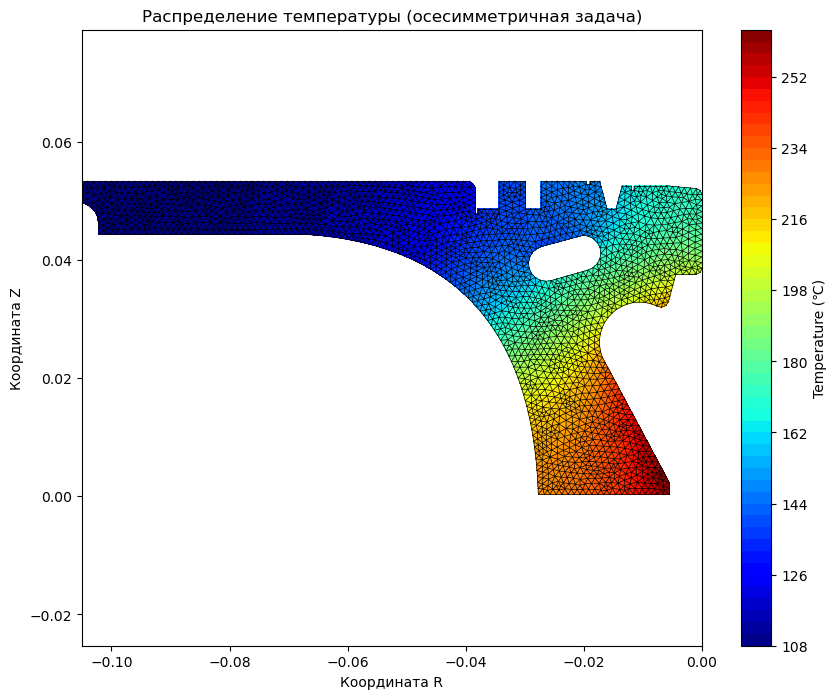

In [68]:
plt.figure(figsize=(10, 8))

triangles = []
for e in range(ne):
    element_nodes = el_list[e]
    valid_nodes = [n for n in element_nodes if n != -1]
    
    if len(valid_nodes) == 3:
        triangles.append(valid_nodes)
    elif len(valid_nodes) == 4:
        # Split the quadrilateral into two triangles
        triangles.append([valid_nodes[0], valid_nodes[1], valid_nodes[2]])
        triangles.append([valid_nodes[0], valid_nodes[2], valid_nodes[3]])

triang = tri.Triangulation(nodes_arr[:, 0], nodes_arr[:, 1], triangles=np.array(triangles))

plt.tricontourf(triang, T_sol, levels=50, cmap='jet')
plt.colorbar(label='Temperature (℃)')
# Add borders
for boundary_name, edges in boundary_edges_map.items():
    for edge in edges:
        n1, n2, _ = edge
        plt.plot([nodes_arr[n1, 0], nodes_arr[n2, 0]], 
                 [nodes_arr[n1, 1], nodes_arr[n2, 1]], 
                 'k-', linewidth=0.5)

plt.title('Распределение температуры (осесимметричная задача)')
plt.xlabel('Координата R')
plt.ylabel('Координата Z')
plt.axis('equal')
plt.show()

In [69]:
# ==================== Интерактивный постпроцессор ====================
import numpy as np
import matplotlib.pyplot as plt

In [70]:
BOUNDARY_HEAT_TRANSFER = {
    'crowntop':   (761,   963-273),   # (α, Tf)：W/(m²·K), ℃
    'crowntop1':  (1065.4, 963-273),
    'crowntop2':  (608.8,  963-273),
    'crowntop3':  (456.6,  963-273),
    'skirt1':     (860,    424.55-273),
    'skirt2':     (1573,   424.55-273),
    'skirt3':     (600,    413.95-273),
    'skirt4':     (1850,   413.95-273),
    'skirt5':     (760,    405.45-273),
    'skirt6':     (1640,   405.45-273),
    'pinbore':    (2000,   90),
    'wallinside': (100,    80),
    'walloutside':(5600,   110),
}

In [71]:
def list_all_boundaries():
    """Вывод списка доступных граничных групп"""
    print("\nДоступные граничные группы:")
    for name in boundary_edges_map.keys():
        if name in BOUNDARY_HEAT_TRANSFER:
            print(f"  - {name} (параметры теплообмена заданы)")
        else:
            print(f"  - {name} (только просмотр температур узлов)")

In [72]:
def compute_boundary_heatflow(boundary_name):
    """Расчёт теплового потока через граничную группу"""
    if boundary_name not in boundary_edges_map:
        print(f"Ошибка: группа '{boundary_name}' не найдена.")
        return None
    edges = boundary_edges_map[boundary_name]
    if not edges:
        print(f"Группа '{boundary_name}' не содержит граней.")
        return None
    if boundary_name not in BOUNDARY_HEAT_TRANSFER:
        print(f"Предупреждение: для '{boundary_name}' не заданы параметры теплообмена.")
        return None
    alpha, Tf = BOUNDARY_HEAT_TRANSFER[boundary_name]
    Q_total = 0.0
    area_sum = 0.0
    T_sum = 0.0
    for n1, n2, L in edges:
        r1, z1 = nodes_arr[n1]
        r2, z2 = nodes_arr[n2]
        r_mid = (r1 + r2) / 2.0
        area = 2.0 * np.pi * r_mid * L   
        T_avg = (T_sol[n1] + T_sol[n2]) / 2.0
        Q_edge = alpha * (T_avg - Tf) * area
        Q_total += Q_edge
        area_sum += area
        T_sum += T_avg * area
    T_mean = T_sum / area_sum if area_sum > 0 else 0.0
    q_mean = Q_total / area_sum if area_sum > 0 else 0.0
    return Q_total, T_mean, q_mean

In [73]:
def list_boundary_nodes(boundary_name):
    """Вывод узлов граничной группы с координатами и температурами"""
    if boundary_name not in boundary_edges_map:
        print(f"Ошибка: группа '{boundary_name}' не найдена.")
        return
    edges = boundary_edges_map[boundary_name]
    if not edges:
        print(f"Группа '{boundary_name}' не содержит граней.")
        return
    node_set = set()
    for n1, n2, _ in edges:
        node_set.add(n1)
        node_set.add(n2)
    node_list = sorted(node_set)
    print(f"\nГруппа '{boundary_name}' (всего узлов: {len(node_list)}):")
    print(f"{'ID узла':>8} {'R (мм)':>10} {'Z (мм)':>10} {'Темп. (℃)':>10}")
    for nid in node_list:
        R, Z = nodes_arr[nid]
        print(f"{nid:8d} {R*1000:10.2f} {Z*1000:10.2f} {T_sol[nid]:10.2f}")

In [74]:
def interactive_postprocess():
    """Главное меню постпроцессора"""
    print("\n" + "="*60)
    print("Интерактивный постпроцессор температурного поля поршня")
    print("="*60)
    while True:
        print("\nВыберите действие:")
        print("  1 – Расчёт теплового потока через границу")
        print("  2 – Просмотр узлов на границе")
        print("  3 – Поиск температуры по координатам")
        print("  4 – Выход")
        choice = input("Введите номер (1-4): ").strip()
        if choice == '1':
            list_all_boundaries()
            name = input("Введите имя граничной группы: ").strip()
            result = compute_boundary_heatflow(name)
            if result:
                Q, T_mean, q_mean = result
                print(f"\nГруппа '{name}':")
                print(f"  Полный тепловой поток = {Q:.1f} Вт")
                print(f"  Средняя температура = {T_mean:.2f} °C")
                print(f"  Средняя плотность теплового потока = {q_mean/1000:.3f} кВт/м²")
        elif choice == '2':
            list_all_boundaries()
            name = input("Введите имя граничной группы: ").strip()
            list_boundary_nodes(name)
        elif choice == '3':
            query_temperature_by_coordinate()
        elif choice == '4':
            break
        else:
            print("Неверный ввод, попробуйте снова.")

In [75]:
interactive_postprocess()


Интерактивный постпроцессор температурного поля поршня

Выберите действие:
  1 – Расчёт теплового потока через границу
  2 – Просмотр узлов на границе
  3 – Поиск температуры по координатам
  4 – Выход


In [76]:
# Итерационный расчёт теплового баланса колец
# Начальные температуры колец
T_ring = [145.0, 138.0, 135.0]   
relax = 0.5
tolerance = 0.5   
max_iter = 30

history = [[], [], []]

print("\n===== Итерационный расчёт теплового баланса колец=====")
print(f"Начальные температуры колец: {T_ring[0]:.1f}°C, {T_ring[1]:.1f}°C, {T_ring[2]:.1f}°C")

# Коэффициенты теплоотдачи контакта
alpha_cont_up1   = 8077.17   
alpha_cont_down1 = 4869.98   
alpha_cont_up2   = 3491.26   
alpha_cont_down2 = 9395.68   
alpha_cont_up3   = 2393.55   
alpha_cont_down3 = 10490.75   

alpha_gas = 350.0            
alpha_in = 350.0             

# Геометрические параметры
D_cyl = 0.105
c1, c2, c3 = 0.0038, 0.0026, 0.0040          # Высота кольца (м)
b1, b2, b3 = 0.0042, 0.004, 0.005           # Радиальная толщина (м)

A_end1 = np.pi * D_cyl * b1    # Площадь торцевой поверхности (контакт между кольцом и стенкой канавки)
A_end2 = np.pi * D_cyl * b2
A_end3 = np.pi * D_cyl * b3

A_radial1 = np.pi * D_cyl * c1  # Площадь внешнего круга (контакт между кольцом и гильзой цилиндра)
A_radial2 = np.pi * D_cyl * c2
A_radial3 = np.pi * D_cyl * c3

A_in1, A_in2, A_in3 = A_end1, A_end2, A_end3  # Внутренняя область (упрощенная)

# Температура газа и температура гильзы баллона (°C)
T_gas1 = 578.37
T_gas2 = 420.0
T_gas3 = 138.89
T_liner = 410.0 - 273.15   

# Средний коэффициент теплопередачи между кольцом и гильзой цилиндра (Вт/(м²·К))
alpha_ring1 = 7266.51
alpha_ring2 = 6782.43
alpha_ring3 = 5340.89

# Коэффициент времени контакта (уже рассчитан)
phi_up1, phi_down1 = 0.6333, 0.3667
phi_up2, phi_down2 = 0.2583, 0.7417
phi_up3, phi_down3 = 0.1681, 0.8319


===== Итерационный расчёт теплового баланса колец=====
Начальные температуры колец: 145.0°C, 138.0°C, 135.0°C


In [77]:
alpha_eq_up1   = phi_up1   * alpha_cont_up1   + (1 - phi_up1)   * alpha_gas
alpha_eq_down1 = phi_down1 * alpha_cont_down1 + (1 - phi_down1) * alpha_gas
alpha_eq_up2   = phi_up2   * alpha_cont_up2   + (1 - phi_up2)   * alpha_gas
alpha_eq_down2 = phi_down2 * alpha_cont_down2 + (1 - phi_down2) * alpha_gas
alpha_eq_up3   = phi_up3   * alpha_cont_up3   + (1 - phi_up3)   * alpha_gas
alpha_eq_down3 = phi_down3 * alpha_cont_down3 + (1 - phi_down3) * alpha_gas

print("\n" + "="*70)
print("Таблица 4.6. Эквивалентный коэффициент теплопередачи на стороне кольцевой канавки")
print("="*70)
print(f"{'граница':<45} {'α_eq (Вт/(м²·К))':>20}")
print("-"*70)
print(f"{'Верхняя торцевая поверхность первой кольцевой канавки':<45} {alpha_eq_up1:>20.1f}")
print(f"{'Нижняя торцевая поверхность первой кольцевой канавки':<45} {alpha_eq_down1:>20.1f}")
print(f"{'Верхняя торцевая поверхность второй кольцевой канавки':<45} {alpha_eq_up2:>20.1f}")
print(f"{'Нижняя торцевая поверхность второй кольцевой канавки':<45} {alpha_eq_down2:>20.1f}")
print(f"{'Верхняя торцевая поверхность третьей кольцевой канавки':<45} {alpha_eq_up3:>20.1f}")
print(f"{'Нижняя торцевая поверхность третьей кольцевой канавки':<45} {alpha_eq_down3:>20.1f}")
print("="*70)


Таблица 4.6. Эквивалентный коэффициент теплопередачи на стороне кольцевой канавки
граница                                           α_eq (Вт/(м²·К))
----------------------------------------------------------------------
Верхняя торцевая поверхность первой кольцевой канавки               5243.6
Нижняя торцевая поверхность первой кольцевой канавки               2007.5
Верхняя торцевая поверхность второй кольцевой канавки               1161.4
Нижняя торцевая поверхность второй кольцевой канавки               7059.2
Верхняя торцевая поверхность третьей кольцевой канавки                693.5
Нижняя торцевая поверхность третьей кольцевой канавки               8786.1


In [78]:
def build_local_stiffness():   
    """Сборка локальной матрицы жёсткости"""
    nn = len(nodes_arr)
    ne = len(el_list)
    k_mat = np.zeros((nn, nn))
    
    for e in tqdm(range(ne), desc="Сборка матрицы жёсткости"):
        element_nodes = el_list[e]
        valid_nodes = [n for n in element_nodes if n != -1]
        if len(valid_nodes) < 3:
            continue
        if len(valid_nodes) == 4:
            tri1 = valid_nodes[:3]
            tri2 = [valid_nodes[0], valid_nodes[2], valid_nodes[3]]
            k_e1, _ = calculate_element_stiffness(nodes_arr, tri1)
            indices1 = np.array(tri1)
            k_mat[np.ix_(indices1, indices1)] += k_e1 * k
            k_e2, _ = calculate_element_stiffness(nodes_arr, tri2)
            indices2 = np.array(tri2)
            k_mat[np.ix_(indices2, indices2)] += k_e2 * k
        else:
            k_e, _ = calculate_element_stiffness(nodes_arr, valid_nodes)
            indices = np.array(valid_nodes)
            k_mat[np.ix_(indices, indices)] += k_e * k
    return k_mat

In [79]:
def apply_local_bc(boundary_edges, h, Tf, k_mat, f_vec):
    """Наложение ГУ 3-го рода на локальную матрицу"""
    if boundary_edges is None:
        return
    for edge in boundary_edges:
        n1, n2, L = edge
        R1, Z1 = nodes_arr[n1]
        R2, Z2 = nodes_arr[n2]
        floc = np.array([np.pi * (2*R1 + R2) * L / 6.0, np.pi * (R1 + 2*R2) * L / 6.0])
        kloc = np.array([[np.pi * (3*R1 + R2) * L / 12.0, np.pi * (R1 + R2) * L / 12.0],
                         [np.pi * (R1 + R2) * L / 12.0, np.pi * (R1 + 3*R2) * L / 12.0]])
        k_mat[n1, n1] += kloc[0,0] * h
        k_mat[n1, n2] += kloc[0,1] * h
        k_mat[n2, n1] += kloc[1,0] * h
        k_mat[n2, n2] += kloc[1,1] * h
        f_vec[n1] += floc[0] * h * Tf
        f_vec[n2] += floc[1] * h * Tf

In [80]:
# Основной итерационный цикл
for it in range(max_iter):
    # Шаг A: Расчёт эквивалентных коэффициентов и температур
    alpha_eq_up1   = phi_up1   * alpha_cont_up1   + (1 - phi_up1)   * alpha_gas
    alpha_eq_down1 = phi_down1 * alpha_cont_down1 + (1 - phi_down1) * alpha_gas
    alpha_eq_up2   = phi_up2   * alpha_cont_up2   + (1 - phi_up2)   * alpha_gas
    alpha_eq_down2 = phi_down2 * alpha_cont_down2 + (1 - phi_down2) * alpha_gas
    alpha_eq_up3   = phi_up3   * alpha_cont_up3   + (1 - phi_up3)   * alpha_gas
    alpha_eq_down3 = phi_down3 * alpha_cont_down3 + (1 - phi_down3) * alpha_gas

    T_eq_up1   = (phi_up1   * alpha_cont_up1   * T_ring[0] + (1 - phi_up1)   * alpha_gas * T_gas1) / alpha_eq_up1
    T_eq_down1 = (phi_down1 * alpha_cont_down1 * T_ring[0] + (1 - phi_down1) * alpha_gas * T_gas1) / alpha_eq_down1
    T_eq_up2   = (phi_up2   * alpha_cont_up2   * T_ring[1] + (1 - phi_up2)   * alpha_gas * T_gas2) / alpha_eq_up2
    T_eq_down2 = (phi_down2 * alpha_cont_down2 * T_ring[1] + (1 - phi_down2) * alpha_gas * T_gas2) / alpha_eq_down2
    T_eq_up3   = (phi_up3   * alpha_cont_up3   * T_ring[2] + (1 - phi_up3)   * alpha_gas * T_gas3) / alpha_eq_up3
    T_eq_down3 = (phi_down3 * alpha_cont_down3 * T_ring[2] + (1 - phi_down3) * alpha_gas * T_gas3) / alpha_eq_down3

    # Шаг B: Сборка и решение
    k_mat = build_local_stiffness()
    f_vec = np.zeros(len(nodes_arr))

    apply_local_bc(boundary_edges_map.get("crowntop1"), 608.8, 963-273, k_mat, f_vec)
    apply_local_bc(boundary_edges_map.get("crowntop2"), 1065.4, 963-273, k_mat, f_vec)
    apply_local_bc(boundary_edges_map.get("crowntop3"), 456.6, 963-273, k_mat, f_vec)
    apply_local_bc(boundary_edges_map.get("pinbore"), 2000, 90, k_mat, f_vec)
    apply_local_bc(boundary_edges_map.get("crowntop"), 761, 963-273, k_mat, f_vec)
    apply_local_bc(boundary_edges_map.get("wallinside"), 100, 80, k_mat, f_vec)
    apply_local_bc(boundary_edges_map.get("walloutside"), 5600, 110, k_mat, f_vec)

    apply_local_bc(boundary_edges_map.get("skirt1"), alpha_eq_up1, T_eq_up1, k_mat, f_vec)
    apply_local_bc(boundary_edges_map.get("skirt2"), alpha_eq_down1, T_eq_down1, k_mat, f_vec)
    apply_local_bc(boundary_edges_map.get("skirt3"), alpha_eq_up2, T_eq_up2, k_mat, f_vec)
    apply_local_bc(boundary_edges_map.get("skirt4"), alpha_eq_down2, T_eq_down2, k_mat, f_vec)
    apply_local_bc(boundary_edges_map.get("skirt5"), alpha_eq_up3, T_eq_up3, k_mat, f_vec)
    apply_local_bc(boundary_edges_map.get("skirt6"), alpha_eq_down3, T_eq_down3, k_mat, f_vec)

    T_sol_local = np.linalg.solve(k_mat, f_vec)

    # Шаг C: Извлечение температур металла в канавках
    def get_avg_temp(boundary_name):
        edges = boundary_edges_map.get(boundary_name)
        if edges:
            temps = []
            for n1, n2, _ in edges:
                temps.append(T_sol_local[n1])
                temps.append(T_sol_local[n2])
            return np.mean(temps)
        else:
            return T_gas1   # fallback

    T_groove_up1   = get_avg_temp("skirt1")
    T_groove_down1 = get_avg_temp("skirt2")
    T_groove_up2   = get_avg_temp("skirt3")
    T_groove_down2 = get_avg_temp("skirt4")
    T_groove_up3   = get_avg_temp("skirt5")
    T_groove_down3 = get_avg_temp("skirt6")

    # Шаг D: Расчёт новых температур колец по тепловому балансу
    Q1_up   = (phi_up1   * alpha_cont_up1   * (T_ring[0] - T_groove_up1) +
               (1-phi_up1) * alpha_gas      * (T_ring[0] - T_gas1)) * A_end1
    Q1_down = (phi_down1 * alpha_cont_down1 * (T_ring[0] - T_groove_down1) +
               (1-phi_down1) * alpha_gas    * (T_ring[0] - T_gas1)) * A_end1
    Q2_1    = alpha_in * A_in1 * (T_ring[0] - T_gas1)
    Q0_1    = alpha_ring1 * A_radial1 * (T_ring[0] - T_liner)
    denom1 = (alpha_ring1 * A_radial1 +
              phi_up1 * alpha_cont_up1 * A_end1 +
              phi_down1 * alpha_cont_down1 * A_end1 +
              (1-phi_up1) * alpha_gas * A_end1 +
              (1-phi_down1) * alpha_gas * A_end1 +
              alpha_in * A_in1)
    numer1 = (alpha_ring1 * A_radial1 * T_liner +
              phi_up1 * alpha_cont_up1 * A_end1 * T_groove_up1 +
              phi_down1 * alpha_cont_down1 * A_end1 * T_groove_down1 +
              (1-phi_up1) * alpha_gas * A_end1 * T_gas1 +
              (1-phi_down1) * alpha_gas * A_end1 * T_gas1 +
              alpha_in * A_in1 * T_gas1)
    T_new1 = numer1 / denom1

    denom2 = (alpha_ring2 * A_radial2 +
              phi_up2 * alpha_cont_up2 * A_end2 +
              phi_down2 * alpha_cont_down2 * A_end2 +
              (1-phi_up2) * alpha_gas * A_end2 +
              (1-phi_down2) * alpha_gas * A_end2 +
              alpha_in * A_in2)
    numer2 = (alpha_ring2 * A_radial2 * T_liner +
              phi_up2 * alpha_cont_up2 * A_end2 * T_groove_up2 +
              phi_down2 * alpha_cont_down2 * A_end2 * T_groove_down2 +
              (1-phi_up2) * alpha_gas * A_end2 * T_gas2 +
              (1-phi_down2) * alpha_gas * A_end2 * T_gas2 +
              alpha_in * A_in2 * T_gas2)
    T_new2 = numer2 / denom2

    denom3 = (alpha_ring3 * A_radial3 +
              phi_up3 * alpha_cont_up3 * A_end3 +
              phi_down3 * alpha_cont_down3 * A_end3 +
              (1-phi_up3) * alpha_gas * A_end3 +
              (1-phi_down3) * alpha_gas * A_end3 +
              alpha_in * A_in3)
    numer3 = (alpha_ring3 * A_radial3 * T_liner +
              phi_up3 * alpha_cont_up3 * A_end3 * T_groove_up3 +
              phi_down3 * alpha_cont_down3 * A_end3 * T_groove_down3 +
              (1-phi_up3) * alpha_gas * A_end3 * T_gas3 +
              (1-phi_down3) * alpha_gas * A_end3 * T_gas3 +
              alpha_in * A_in3 * T_gas3)
    T_new3 = numer3 / denom3

    T_new = [T_new1, T_new2, T_new3]

    # Релаксация
    for i in range(3):
        T_ring[i] = relax * T_new[i] + (1 - relax) * T_ring[i]
        history[i].append(T_ring[i])

    print(f"Итерация {it+1}: T_кольца = {T_ring[0]:.2f}°C, {T_ring[1]:.2f}°C, {T_ring[2]:.2f}°C")

    if it > 0:
        delta = max(abs(history[i][-1] - history[i][-2]) for i in range(3))
        if delta < tolerance:
            print(f"\nСходимость достигнута на итерации {it+1}")
            break

Сборка матрицы жёсткости:   0%|          | 0/4080 [00:00<?, ?it/s]

Итерация 1: T_кольца = 159.05°C, 147.42°C, 133.24°C


Сборка матрицы жёсткости:   0%|          | 0/4080 [00:00<?, ?it/s]

Итерация 2: T_кольца = 167.30°C, 153.35°C, 132.53°C


Сборка матрицы жёсткости:   0%|          | 0/4080 [00:00<?, ?it/s]

...

Итерация 6: T_кольца = 177.73°C, 161.82°C, 132.43°C


Сборка матрицы жёсткости:   0%|          | 0/4080 [00:00<?, ?it/s]

Итерация 7: T_кольца = 178.33°C, 162.40°C, 132.49°C


Сборка матрицы жёсткости:   0%|          | 0/4080 [00:00<?, ?it/s]

Итерация 8: T_кольца = 178.69°C, 162.76°C, 132.55°C

Сходимость достигнута на итерации 8


In [81]:
# Вывод результатов
print("\n===== Конечные температуры колец =====")
print(f"Первое кольцо: {T_ring[0]:.1f} °C ({T_ring[0]+273.15:.1f} K)")
print(f"Второе кольцо: {T_ring[1]:.1f} °C ({T_ring[1]+273.15:.1f} K)")
print(f"Третье кольцо: {T_ring[2]:.1f} °C ({T_ring[2]+273.15:.1f} K)")

print("\n===== Температуры металла в канавках =====")
print(f"Первое кольцо, верхняя грань: {T_groove_up1:.1f} °C ({T_groove_up1+273.15:.1f} K)")
print(f"Первое кольцо, нижняя грань:  {T_groove_down1:.1f} °C ({T_groove_down1+273.15:.1f} K)")
print(f"Второе кольцо, верхняя грань: {T_groove_up2:.1f} °C ({T_groove_up2+273.15:.1f} K)")
print(f"Второе кольцо, нижняя грань:  {T_groove_down2:.1f} °C ({T_groove_down2+273.15:.1f} K)")
print(f"Третье кольцо, верхняя грань: {T_groove_up3:.1f} °C ({T_groove_up3+273.15:.1f} K)")
print(f"Третье кольцо, нижняя грань:  {T_groove_down3:.1f} °C ({T_groove_down3+273.15:.1f} K)")


===== Конечные температуры колец =====
Первое кольцо: 178.7 °C (451.8 K)
Второе кольцо: 162.8 °C (435.9 K)
Третье кольцо: 132.5 °C (405.7 K)

===== Температуры металла в канавках =====
Первое кольцо, верхняя грань: 181.7 °C (454.8 K)
Первое кольцо, нижняя грань:  170.3 °C (443.5 K)
Второе кольцо, верхняя грань: 161.8 °C (434.9 K)
Второе кольцо, нижняя грань:  154.1 °C (427.3 K)
Третье кольцо, верхняя грань: 151.0 °C (424.2 K)
Третье кольцо, нижняя грань:  129.2 °C (402.3 K)


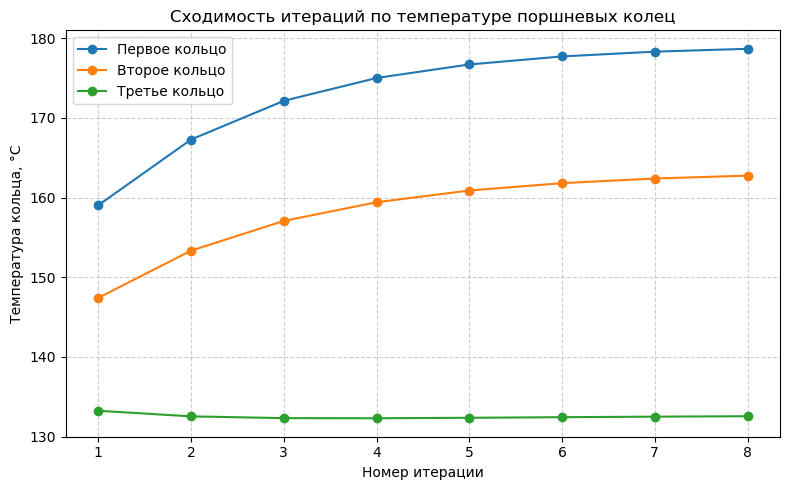

In [82]:
# График сходимости
plt.figure(figsize=(8,5))
for i, label in enumerate(['Первое кольцо', 'Второе кольцо', 'Третье кольцо']):
    plt.plot(range(1, len(history[i])+1), history[i], marker='o', label=label)
plt.xlabel('Номер итерации')
plt.ylabel('Температура кольца, °C')
plt.title('Сходимость итераций по температуре поршневых колец')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

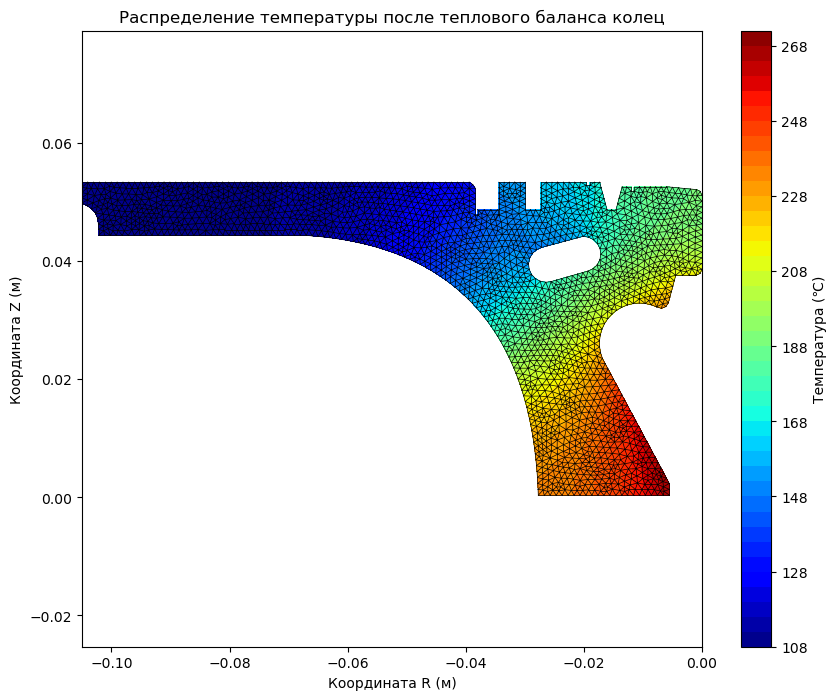

In [83]:
# Финальное распределение температуры (после итераций)
plt.figure(figsize=(10, 8))

triangles = []
for e in range(ne):
    element_nodes = el_list[e]
    valid_nodes = [n for n in element_nodes if n != -1]
    if len(valid_nodes) == 3:
        triangles.append(valid_nodes)
    elif len(valid_nodes) == 4:
        triangles.append([valid_nodes[0], valid_nodes[1], valid_nodes[2]])
        triangles.append([valid_nodes[0], valid_nodes[2], valid_nodes[3]])

triang = tri.Triangulation(nodes_arr[:, 0], nodes_arr[:, 1], triangles=np.array(triangles))

plt.tricontourf(triang, T_sol_local, levels=50, cmap='jet')
plt.colorbar(label='Температура (℃)')

for boundary_name, edges in boundary_edges_map.items():
    for edge in edges:
        n1, n2, _ = edge
        plt.plot([nodes_arr[n1, 0], nodes_arr[n2, 0]], 
                 [nodes_arr[n1, 1], nodes_arr[n2, 1]], 
                 'k-', linewidth=0.5)

plt.title('Распределение температуры после теплового баланса колец')
plt.xlabel('Координата R (м)')
plt.ylabel('Координата Z (м)')
plt.axis('equal')
plt.show()

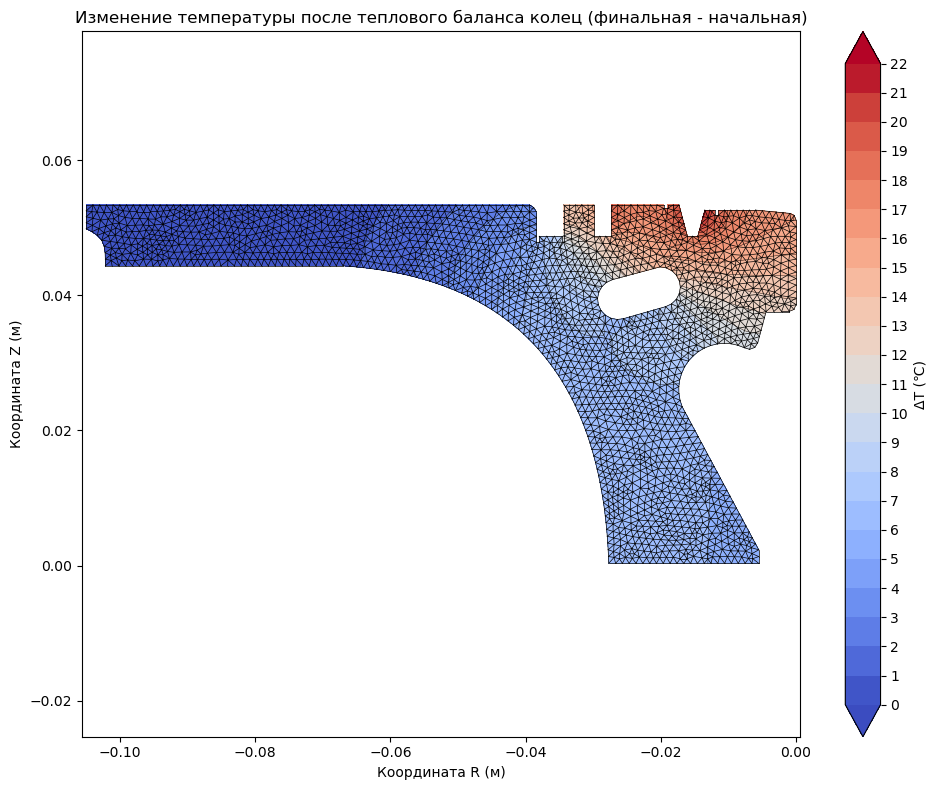

Диапазон изменения температуры: 0.06 ℃ ... 21.11 ℃
Среднее изменение температуры: 6.62 ℃


In [84]:
# Разница температур (финальная - начальная)
T_diff = T_sol_local - T_sol

min_diff = np.floor(T_diff.min())
max_diff = np.ceil(T_diff.max())
levels = np.arange(min_diff, max_diff + 0.1, 1.0)

plt.figure(figsize=(10,8))
contour = plt.tricontourf(triang, T_diff, levels=levels, cmap='coolwarm', extend='both')
plt.colorbar(contour, label='ΔT (℃)', ticks=levels)
plt.tricontour(triang, T_diff, levels=levels, colors='k', linewidths=0.3)

for boundary_name, edges in boundary_edges_map.items():
    for edge in edges:
        n1, n2, _ = edge
        plt.plot([nodes_arr[n1, 0], nodes_arr[n2, 0]], 
                 [nodes_arr[n1, 1], nodes_arr[n2, 1]], 
                 'k-', linewidth=0.5)

plt.title('Изменение температуры после теплового баланса колец (финальная - начальная)')
plt.xlabel('Координата R (м)')
plt.ylabel('Координата Z (м)')
plt.axis('equal')
plt.tight_layout()
plt.show()

print(f"Диапазон изменения температуры: {np.min(T_diff):.2f} ℃ ... {np.max(T_diff):.2f} ℃")
print(f"Среднее изменение температуры: {np.mean(T_diff):.2f} ℃")

In [85]:
# Финальный интерактивный постпроцессор
FINAL_BOUNDARY_HEAT_TRANSFER = BOUNDARY_HEAT_TRANSFER.copy()
FINAL_BOUNDARY_HEAT_TRANSFER.update({
    'skirt1': (alpha_eq_up1,   T_ring[0]),
    'skirt2': (alpha_eq_down1, T_ring[0]),
    'skirt3': (alpha_eq_up2,   T_ring[1]),
    'skirt4': (alpha_eq_down2, T_ring[1]),
    'skirt5': (alpha_eq_up3,   T_ring[2]),
    'skirt6': (alpha_eq_down3, T_ring[2]),
})

def list_all_boundaries_final():
    print("\nДоступные граничные группы (финальное поле):")
    for name in boundary_edges_map.keys():
        if name in FINAL_BOUNDARY_HEAT_TRANSFER:
            print(f"  - {name} (параметры обновлены)")
        else:
            print(f"  - {name} (только просмотр)")

def compute_boundary_heatflow_final(boundary_name):
    if boundary_name not in boundary_edges_map:
        print(f"Ошибка: группа '{boundary_name}' не найдена.")
        return None
    edges = boundary_edges_map[boundary_name]
    if not edges:
        print(f"Группа '{boundary_name}' не содержит граней.")
        return None
    if boundary_name not in FINAL_BOUNDARY_HEAT_TRANSFER:
        print(f"Предупреждение: для '{boundary_name}' не заданы параметры теплообмена.")
        return None
    alpha, Tf = FINAL_BOUNDARY_HEAT_TRANSFER[boundary_name]
    Q_total = 0.0
    area_sum = 0.0
    T_sum = 0.0
    for n1, n2, L in edges:
        r1, z1 = nodes_arr[n1]
        r2, z2 = nodes_arr[n2]
        r_mid = (r1 + r2) / 2.0
        area = 2.0 * np.pi * r_mid * L
        T_avg = (T_sol_local[n1] + T_sol_local[n2]) / 2.0
        Q_edge = alpha * (T_avg - Tf) * area
        Q_total += Q_edge
        area_sum += area
        T_sum += T_avg * area
    T_mean = T_sum / area_sum if area_sum > 0 else 0.0
    q_mean = Q_total / area_sum if area_sum > 0 else 0.0
    return Q_total, T_mean, q_mean

def list_boundary_nodes_final(boundary_name):
    if boundary_name not in boundary_edges_map:
        print(f"Ошибка: группа '{boundary_name}' не найдена.")
        return
    edges = boundary_edges_map[boundary_name]
    if not edges:
        print(f"Группа '{boundary_name}' не содержит граней.")
        return
    node_set = set()
    for n1, n2, _ in edges:
        node_set.add(n1)
        node_set.add(n2)
    node_list = sorted(node_set)
    print(f"\nГруппа '{boundary_name}' (всего узлов: {len(node_list)}):")
    print(f"{'ID узла':>8} {'R (мм)':>10} {'Z (мм)':>10} {'Темп. (℃)':>10}")
    for nid in node_list:
        R, Z = nodes_arr[nid]
        print(f"{nid:8d} {R*1000:10.2f} {Z*1000:10.2f} {T_sol_local[nid]:10.2f}")

def interactive_postprocess_final():
    print("\n" + "="*60)
    print("Финальный постпроцессор температурного поля (после итераций)")
    print("="*60)
    while True:
        print("\nВыберите действие:")
        print("  1 – Расчёт теплового потока через границу")
        print("  2 – Просмотр узлов на границе")
        print("  3 – Выход")
        choice = input("Введите номер (1-3): ").strip()
        if choice == '1':
            list_all_boundaries_final()
            name = input("Введите имя граничной группы: ").strip()
            result = compute_boundary_heatflow_final(name)
            if result:
                Q, T_mean, q_mean = result
                print(f"\nГруппа '{name}':")
                print(f"  Полный тепловой поток = {Q:.1f} Вт")
                print(f"  Средняя температура = {T_mean:.2f} °C")
                print(f"  Средняя плотность теплового потока = {q_mean/1000:.3f} кВт/м²")
        elif choice == '2':
            list_all_boundaries_final()
            name = input("Введите имя граничной группы: ").strip()
            list_boundary_nodes_final(name)
        elif choice == '3':
            print("Выход из финального постпроцессора.")
            break
        else:
            print("Неверный ввод, попробуйте снова.")

print("\n===== Запуск финального постпроцессора =====")
interactive_postprocess_final()


===== Запуск финального постпроцессора =====

Финальный постпроцессор температурного поля (после итераций)

Выберите действие:
  1 – Расчёт теплового потока через границу
  2 – Просмотр узлов на границе
  3 – Выход
Выход из финального постпроцессора.
